# 10. Latent Semantic Index/Analysis (LSI/A)

* El LSI es una técnica de factorización matricial aplicable al campo del NLP, que tiene como objetivo analizar las relaciones entre los documentos de un corpus y las palabras.


* El LSI asume que las palabras que tienen un significado similar aparecerán en partes de documentos similares.


* El LSI tiene como finalidad extraer una serie de factores latentes que caractericen a los documentos y las palabras del corpus.


* Para ello necesita una matriz de frecuencias que represente el número de veces que aparecen las palabras en los documentos:

    - ***Filas***: Cada fila representa a una palabra.
    - ***Columnas***: Cada columna representa a un documento.
    - ***Celda***: Cada celda representa el número de veces que aparece la palabra en el documento.


* El LSI descompone una matriz "A" (de frecuencias), formada por el número de apariciones de cada palabra en cada documento, en tres matrices "U", "S" y "V" cuyo producto matricial es igual a la matriz original "A":


$$ SVD(A) = U \cdot S \cdot V^{t}$$


* Donde cada una de estas matrices contiene la siguiente información:

    - ***Matriz "U"*** contiene los valores de los ***factores latentes de las palabras***.
    - ***Matriz "V"*** contiene los valores de los ***factores latentes de los documentos***.
    - ***Matriz "S"*** es una matriz en cuya diagonal están los llamados valores singulares, que son decrecientes y no negativos. Esta matriz representa la ***importancia que tiene cada uno de los factores latentes de las palabras y de los documentos***.


<img src="imgs/008_LSI_Matrix.png" style="width: 800px;"/>


* Como la matriz "S" nos informa de la importancia que tiene cada uno de los factores latentes, podemos coger solo los ***K-factores más importantes*** para caracterizar cada una de las palabras y de los documentos.


* De esta forma se trabaja con matrices más reducidas, lo que nos permite comprimir la información de la matriz de apariciones.


* El SVD tiene una propiedad muy importante que viene dada por el ***teorema de Eckart-Young***, que afirma que la mejor aproximación a la matriz "A" la obtenemos poniendo a cero los valores singulares de menor a mayor valor; es decir, reduciendo la matriz "S". Por tanto, si multiplicásemos las submatrices "U<sub>k</sub>", "S<sub>k</sub>" y "V<sub>k</sub>" obtendríamos una matriz A' de rango K que mejor aproxima (de acuerdo con la norma de Frobenius) a la matriz "A".


<img src="imgs/009_LSI_Matrix_reduc.png" style="width: 800px;"/>


* El valor de K va a representar el número de temas en que vamos a dividir (o clusterizar) nuestro corpus; por tanto, la selección del número de temas es un valor que tenemos que definir a priori.


* Para poder trabajar en la extracción de tópicos y ver las relaciones entre los documentos y las palabras, vamos a trabajar con las matrices:

    - ***U<sub>k</sub>***: Estudiar las relaciones entre palabras
    - ***V<sub>k</sub>***: Estudiar las relaciones entre documentos
    - ***K***: Número de temas que tendrá a priori el corpus


<hr>

# Ejemplo de LSI con Gensim

* Veamos a continuación un ejemplo sencillo sobre el siguiente corpus, del cual podemos ver que habla de 3 temas deportivos:
    - Fútbol
    - Baloncesto
    - Tenis

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Corpus principal: tres temáticas deportivas (fútbol, baloncesto, tenis)
corpus = [
    # Fútbol
    'gol gol gol messi messi messi messi ronaldo ronaldo liga liga champions champions',
    'futbol futbol futbol gol gol portero portero delantero delantero penalti estadio',
    'gol gol liga liga liga champions champions copa copa messi messi ronaldo ronaldo neymar neymar',
    'penalti penalti arbitro arbitro arbitro arbitro balon balon futbol futbol gol gol estadio estadio',
    # Baloncesto
    'canasta canasta triple triple rebote rebote gol nba nba lebron lebron jordan jordan',
    'baloncesto baloncesto nba nba euroliga euroliga pivot pivot base base alero alero',
    'triple triple canasta canasta lebron jordan jordan gol pabellon pabellon rebote rebote mate mate',
    'nba nba nba lebron lebron canasta canasta triple baloncesto pabellon pabellon euroliga',
    # Tenis
    'tenis tenis nadal nadal djokovic djokovic federer federer gol wimbledon roland_garros saque saque',
    'raqueta raqueta saque saque set set game game nadal pelota pelota gol torneo torneo',
    'wimbledon wimbledon roland_garros roland_garros federer federer djokovic djokovic tenis tenis open open'
]

## Creamos el Diccionario y la Matriz (Bolsa de Palabras)

In [2]:
from pprint import pprint
from gensim import corpora
from collections import defaultdict

# Tokenizamos
documents = [doc.split() for doc in corpus]

# Creamos el diccionario (vocabulario)
frequency = defaultdict(int)
for doc in documents:
    for token in doc:
        frequency[token] += 1

dictionary = corpora.Dictionary(documents)
print('Diccionario:')
pprint(dictionary.token2id)

# Creamos la Bolsa de Palabras
corpus_bow = [dictionary.doc2bow(doc) for doc in documents]
print('\nBolsa de Palabras:')
pprint(corpus_bow)

Diccionario:
{'alero': 20,
 'arbitro': 12,
 'balon': 13,
 'baloncesto': 21,
 'base': 22,
 'canasta': 14,
 'champions': 0,
 'copa': 10,
 'delantero': 5,
 'djokovic': 27,
 'estadio': 6,
 'euroliga': 23,
 'federer': 28,
 'futbol': 7,
 'game': 34,
 'gol': 1,
 'jordan': 15,
 'lebron': 16,
 'liga': 2,
 'mate': 25,
 'messi': 3,
 'nadal': 29,
 'nba': 17,
 'neymar': 11,
 'open': 39,
 'pabellon': 26,
 'pelota': 35,
 'penalti': 8,
 'pivot': 24,
 'portero': 9,
 'raqueta': 36,
 'rebote': 18,
 'roland_garros': 30,
 'ronaldo': 4,
 'saque': 31,
 'set': 37,
 'tenis': 32,
 'torneo': 38,
 'triple': 19,
 'wimbledon': 33}

Bolsa de Palabras:
[[(0, 2), (1, 3), (2, 2), (3, 4), (4, 2)],
 [(1, 2), (5, 2), (6, 1), (7, 3), (8, 1), (9, 2)],
 [(0, 2), (1, 2), (2, 3), (3, 2), (4, 2), (10, 2), (11, 2)],
 [(1, 2), (6, 2), (7, 2), (8, 2), (12, 4), (13, 2)],
 [(1, 1), (14, 2), (15, 2), (16, 2), (17, 2), (18, 2), (19, 2)],
 [(17, 2), (20, 2), (21, 2), (22, 2), (23, 2), (24, 2)],
 [(1, 1), (14, 2), (15, 2), (16, 1), (18,

## Creamos el Modelo

* Gensim tiene implementado el LSI en la clase ***LsiModel***: https://radimrehurek.com/gensim/models/lsimodel.html


* Como parámetros relevantes necesita:
    1. Corpus
    2. Número de Topics
    3. Diccionario o Vocabulario del Corpus

In [3]:
from gensim.models import LsiModel

# random_seed fijo: el signo de los factores del SVD es arbitrario y puede
# variar entre ejecuciones: fijar la semilla hace el resultado reproducible.
lsi_model = LsiModel(corpus=corpus_bow, num_topics=3, id2word=dictionary, random_seed=42)

### Matriz U

* En esta matriz obtenemos los ***factores latentes de cada una de las palabras del corpus***

In [4]:
u_matrix = lsi_model.projection.u
u_matrix

array([[ 0.27331627,  0.14250893,  0.17429794],
       [ 0.56273936,  0.0826555 , -0.1546917 ],
       [ 0.33781634,  0.17766393,  0.22069213],
       [ 0.41763241,  0.21470786,  0.2558075 ],
       [ 0.27331627,  0.14250893,  0.17429794],
       [ 0.05711416,  0.01406748, -0.10237908],
       [ 0.10080505,  0.02643394, -0.22127543],
       [ 0.15791922,  0.04050142, -0.3236545 ],
       [ 0.10080505,  0.02643394, -0.22127543],
       [ 0.05711416,  0.01406748, -0.10237908],
       [ 0.12900014,  0.07031   ,  0.09278839],
       [ 0.12900014,  0.07031   ,  0.09278839],
       [ 0.14449594,  0.03880041, -0.34017178],
       [ 0.07224797,  0.0194002 , -0.17008589],
       [ 0.15574913, -0.41153297,  0.03477392],
       [ 0.11780959, -0.27343462,  0.01496441],
       [ 0.12686018, -0.34647667,  0.03192184],
       [ 0.13010517, -0.41098568,  0.05229124],
       [ 0.11780959, -0.27343462,  0.01496441],
       [ 0.13677936, -0.3424838 ,  0.02486916],
       [ 0.01316416, -0.06051614,  0.013

* Para ver los factores de cada una de las palabras lo vamos a mostrar de la siguiente manera:

In [5]:
import pandas as pd

pd.DataFrame(u_matrix, columns=['Topic 1', 'Topic 2', 'Topic 3'], index=dictionary.token2id.keys())

,Topic 1,Topic 2,Topic 3
champions,0.273316,0.142509,0.174298
gol,0.562739,0.082656,-0.154692
liga,0.337816,0.177664,0.220692
messi,0.417632,0.214708,0.255807
ronaldo,0.273316,0.142509,0.174298
delantero,0.057114,0.014067,-0.102379
estadio,0.100805,0.026434,-0.221275
futbol,0.157919,0.040501,-0.323655
penalti,0.100805,0.026434,-0.221275
portero,0.057114,0.014067,-0.102379


### Matriz S

* En esta matriz obtenemos la importancia de los ***factores latentes***

In [6]:
s_matrix = lsi_model.projection.s
s_matrix

array([8.42978599, 7.50289247, 6.4542408 ])

### Matriz V

* En esta matriz obtenemos los ***factores latentes de cada uno de los documentos del corpus***

In [7]:
from gensim.matutils import corpus2dense

v_matrix = corpus2dense(lsi_model[corpus_bow], len(lsi_model.projection.s)).T / lsi_model.projection.s
v_matrix

array([[ 0.60827707,  0.27085041,  0.26304115],
       [ 0.24073008,  0.05277339, -0.33038961],
       [ 0.5437218 ,  0.26376418,  0.29943929],
       [ 0.30451747,  0.07277882, -0.54888765],
       [ 0.25302722, -0.53766483,  0.02988396],
       [ 0.05548551, -0.22702304,  0.04297463],
       [ 0.2435276 , -0.48811046,  0.01840799],
       [ 0.15991108, -0.51806856,  0.06392768],
       [ 0.12515641,  0.02930955, -0.45303348],
       [ 0.11929128,  0.02543708, -0.2231235 ],
       [ 0.04255095,  0.01452163, -0.41051388]])

* Para ver los factores de cada uno de los documentos lo vamos a mostrar de la siguiente manera:

In [8]:
index = ['Doc {}'.format(i + 1) for i, doc in enumerate(documents)]
pd.DataFrame(v_matrix, index=index, columns=['Topic 1', 'Topic 2', 'Topic 3'])

,Topic 1,Topic 2,Topic 3
Doc 1,0.608277,0.270850,0.263041
Doc 2,0.240730,0.052773,-0.330390
Doc 3,0.543722,0.263764,0.299439
Doc 4,0.304517,0.072779,-0.548888
Doc 5,0.253027,-0.537665,0.029884
Doc 6,0.055486,-0.227023,0.042975
Doc 7,0.243528,-0.488110,0.018408
Doc 8,0.159911,-0.518069,0.063928
Doc 9,0.125156,0.029310,-0.453033
Doc 10,0.119291,0.025437,-0.223124


## Conclusiones

* Tras mostrar los valores de los factores latentes de las palabras y de los documentos, podemos ver cómo el valor de los factores guarda cierta relación con el tema del que trata el documento, aunque la relación no es perfecta.


* El **Topic 1** tiene un valor alto para casi todos los documentos y palabras: está dominado por los términos más frecuentes del corpus ("gol", "messi", "liga"...) y actúa más como un factor de "tamaño/frecuencia general" que como un factor discriminativo entre temas. Por eso, para estudiar la separación entre temas conviene fijarse en los **Topics 2 y 3**.


* El **Topic 2** separa de forma muy clara el **baloncesto**: los documentos 5, 6, 7 y 8 tienen valores claramente positivos (entre 0.23 y 0.54), mientras que el resto de documentos tienen valores próximos a cero o negativos. Esto es coherente con que el vocabulario del baloncesto ("canasta", "nba", "lebron", "triple", "rebote", "jordan", "pabellon"...) apenas se solapa con el de los otros dos temas.


* El **Topic 3**, sin embargo, no separa limpiamente fútbol y tenis. Los documentos de fútbol se dividen en dos subgrupos según su vocabulario: los documentos 1 y 3 (centrados en jugadores y competiciones: "messi", "ronaldo", "champions", "liga", "copa", "neymar") tienen Topic 3 positivo, mientras que los documentos 2 y 4 (centrados en el partido y el arbitraje: "futbol", "portero", "delantero", "penalti", "arbitro", "estadio") tienen Topic 3 muy negativo, en un rango parecido al de los documentos de tenis (9, 10 y 11). El resultado es que, en el espacio de los Topics 2 y 3, los documentos 2 y 4 de fútbol quedan visualmente próximos a los documentos de tenis.


* Esto ilustra dos limitaciones reales del LSI con corpus pequeños: (1) la palabra "gol", presente en los tres temas de forma intencionada, "difumina" el espacio latente; y (2) un tema no siempre es lingüísticamente homogéneo: si un tema (aquí, fútbol) contiene documentos con vocabularios muy distintos entre sí, el LSI puede separarlos en factores distintos en lugar de agruparlos, acercando alguno de esos subgrupos a un tema diferente.


* ***NOTA***: *Al tratarse de un ejemplo didáctico podemos hacer ciertas suposiciones y representar ciertos conceptos en un espacio reducido; en este caso en 2 dimensiones. En un caso real, con muchos documentos, muchas palabras y muchos temas (topics), será casi imposible visualizar este tipo de cosas con el LSI.*

### Representación visual de los documentos en 2D

* Representamos los **Topics 2 y 3** (no el Topic 1, que como hemos visto no es discriminativo) para poder apreciar mejor la estructura descrita arriba: el baloncesto se agrupa de forma clara, mientras que el fútbol se reparte entre dos zonas, una de las cuales queda cercana a los documentos de tenis.

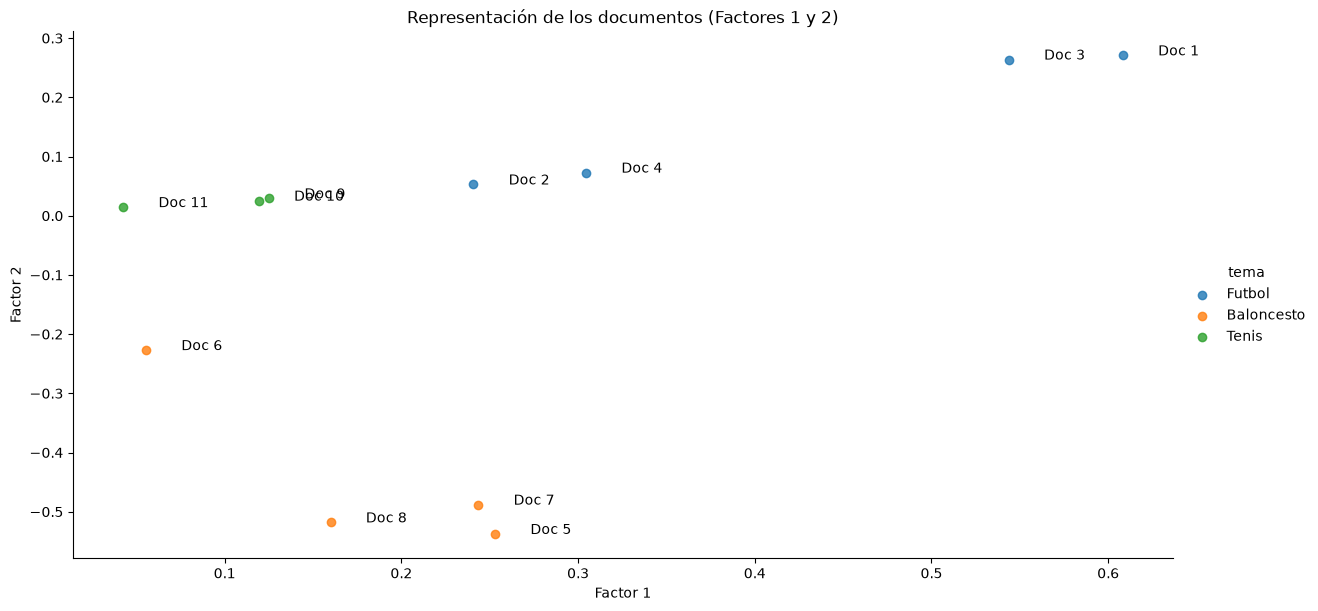

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

temas = ['Futbol'] * 4 + ['Baloncesto'] * 4 + ['Tenis'] * 3

df_docs = pd.DataFrame({'f1': v_matrix[:, 0], 'f2': v_matrix[:, 1],
                        'grupo': ['Doc {}'.format(i + 1) for i, doc in enumerate(documents)],
                        'tema': temas})

sns.lmplot(data=df_docs, x='f1', y='f2', hue='tema', fit_reg=False, height=6, aspect=2)

plt.title('Representación de los documentos (Factores 1 y 2)')
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')


def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        ax.text(point['x'] + .02, point['y'], str(point['val']))


label_point(df_docs.f1, df_docs.f2, df_docs.grupo, plt.gca())

<hr>

## Topics & Terms

* Cada uno de los temas (***Topics***) está definido por una importancia (o peso) que tienen las palabras (***Terms***) del corpus en el tema.


* Por eso, cada tema tiene unas palabras relevantes que, en función de si aparecen o no en el documento, hacen que este pertenezca más a un tema que a otro.


* Gensim nos devuelve una "fórmula" por tema (Topic) que, aplicada a las apariciones de las palabras en los documentos, nos indica el grado de pertenencia del documento a ese tema. El que mayor valor tenga tras aplicar la fórmula del tema al documento significará que tiene mayor propensión a pertenecer a ese tema.

In [10]:
lsi_model.print_topics()

[(0,
  '0.563*"gol" + 0.418*"messi" + 0.338*"liga" + 0.273*"champions" + 0.273*"ronaldo" + 0.158*"futbol" + 0.156*"canasta" + 0.144*"arbitro" + 0.137*"triple" + 0.130*"nba"'),
 (1,
  '-0.412*"canasta" + -0.411*"nba" + -0.346*"lebron" + -0.342*"triple" + -0.273*"rebote" + -0.273*"jordan" + -0.268*"pabellon" + 0.215*"messi" + 0.178*"liga" + 0.143*"ronaldo"'),
 (2,
  '-0.340*"arbitro" + -0.324*"futbol" + -0.268*"djokovic" + -0.268*"federer" + -0.268*"tenis" + 0.256*"messi" + -0.221*"penalti" + -0.221*"estadio" + 0.221*"liga" + -0.210*"saque"')]

<hr>

# Topics de nuevos documentos

* Al tratarse el Topic Modeling de un aprendizaje no supervisado (básicamente es un clustering de documentos), tenemos que ser capaces de asignar a un nuevo documento el tema al que pertenece.


* Para ello tenemos que:
    1. ***Obtener los factores latentes del nuevo documento*** en función del vector de apariciones de palabras
    2. Calcular la ***similaridad con el resto de documentos*** en función de sus factores latentes


* Para obtener los factores latentes de un nuevo documento lo podemos hacer con la técnica del "***Folding-In***", que básicamente consiste en el siguiente cálculo teniendo las matrices U<sub>k</sub> y S:


$$ FactoresLatentes_{new doc} = VectorPalabras_{new doc} \cdot U_{k} \cdot S^{-1}$$


* Gensim ya tiene implementada esta funcionalidad, y también la del cálculo de similaridades entre documentos:

In [11]:
new_doc = 'canasta lebron triple jordan mate'
new_vec = dictionary.doc2bow(new_doc.split())

In [12]:
# Obtenemos los factores latentes del nuevo documento
vec_lsi = lsi_model[new_vec]

pd.DataFrame(vec_lsi, index=['Topic 1', 'Topic 2', 'Topic 3'], columns=['', 'Valor'])

,,Valor
Topic 1,0,0.594976
Topic 2,1,-1.504041
Topic 3,2,0.112233


* Ahora pasamos a calcular las similaridades entre documentos, y podemos observar cómo este nuevo documento tiene mayor similaridad con los documentos de baloncesto (5, 6, 7 y 8).

In [13]:
from gensim import similarities

# Calculamos las similaridades
index_sim = similarities.MatrixSimilarity(lsi_model[corpus_bow])
sims = index_sim[vec_lsi]
sims = sorted(enumerate(sims), key=lambda item: -item[1])

pd.DataFrame(sims, columns=['Documento (indice)', 'Similaridad'])

,Documento (indice),Similaridad
0,7,0.998617
1,4,0.993645
2,5,0.990446
3,6,0.990192
4,1,0.077358
5,9,0.052236
6,3,0.043147
7,0,0.019763
8,2,-0.003748
9,8,-0.006174
